# STEP 1: Import Required Libraries
# ------------------------------------------
# pandas  -> data handling
# numpy   -> numerical computations
# matplotlib & seaborn -> data visualization
# sklearn -> machine learning models & evaluation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# STEP 2: Load the Dataset
# ------------------------------------------
# Dataset should contain pollutant values and AQI

In [2]:
df = pd.read_csv("city_day.csv")


# Display first few rows

In [3]:
print("First 5 rows of dataset:")
print(df.head())

First 5 rows of dataset:
        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad  2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad  2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad  2015-01-04    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad  2015-01-05    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

       O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  133.36     0.00     0.02    0.00  NaN        NaN  
1   34.06     3.68     5.50    3.77  NaN        NaN  
2   30.70     6.80    16.40    2.25  NaN        NaN  
3   36.08     4.43    10.14    1.00  NaN        NaN  
4   39.31     7.01    18.89    2.78  NaN        NaN  


# STEP 3: Understand the Dataset
# ------------------------------------------
# Check data types, missing values, and structure

In [4]:
print("\nDataset Information:")
print(df.info())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB
None


In [5]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
              PM2.5          PM10            NO           NO2           NOx  \
count  24933.000000  18391.000000  25949.000000  25946.000000  25346.000000   
mean      67.450578    118.127103     17.574730     28.560659     32.309123   
std       64.661449     90.605110     22.785846     24.474746     31.646011   
min        0.040000      0.010000      0.020000      0.010000      0.000000   
25%       28.820000     56.255000      5.630000     11.750000     12.820000   
50%       48.570000     95.680000      9.890000     21.690000     23.520000   
75%       80.590000    149.745000     19.950000     37.620000     40.127500   
max      949.990000   1000.000000    390.680000    362.210000    467.630000   

                NH3            CO           SO2            O3       Benzene  \
count  19203.000000  27472.000000  25677.000000  25509.000000  23908.000000   
mean      23.483476      2.248598     14.531977     34.491430      3.280840   
std       25.684275      6.96

# STEP 4: Handle Missing Values
# ------------------------------------------
# ML models cannot handle missing values directly


In [6]:
df = df.dropna()

print("\nMissing values removed. Updated dataset shape:", df.shape)


Missing values removed. Updated dataset shape: (6236, 16)



# STEP 5: Exploratory Data Analysis (EDA)
# ------------------------------------------
# Correlation heatmap to understand relationship between features

In [7]:
print(df.dtypes)


City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket     object
dtype: object


In [8]:
numeric_df = df.select_dtypes(include='number')


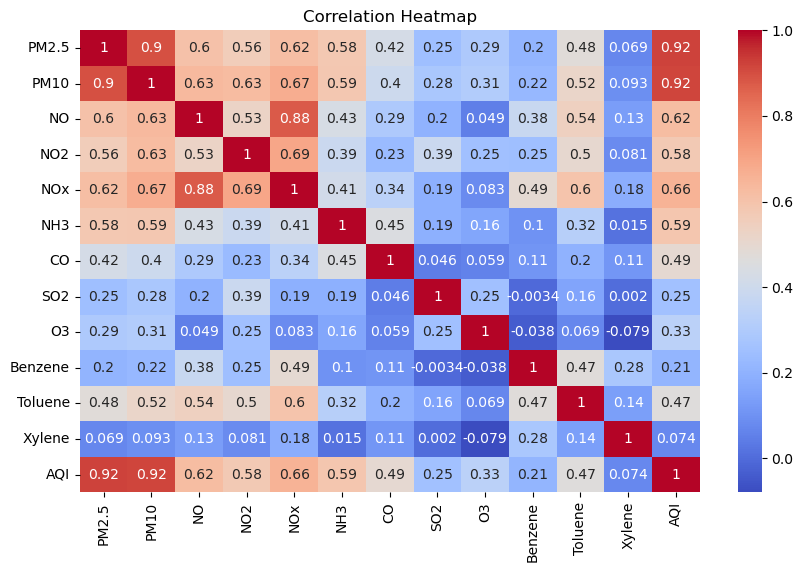

In [9]:
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


# STEP 6: Feature Selection
# ------------------------------------------
# X -> independent variables (pollutants)
# y -> dependent variable (AQI)

In [10]:
X = df[['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3']]
y = df['AQI']


# STEP 7: Train-Test Split
# ------------------------------------------
# 80% training data, 20% testing data

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
print("\nTraining set size:", X_train.shape)
print("Testing set size:", X_test.shape)



Training set size: (4988, 6)
Testing set size: (1248, 6)


# STEP 8: Create and Train Linear Regression Model
# ------------------------------------------

In [13]:
model = LinearRegression()
model.fit(X_train, y_train)

print("\nModel training completed.")


Model training completed.


# STEP 9: Make Predictions
# ------------------------------------------

In [14]:
y_pred = model.predict(X_test)

# STEP 10: Evaluate Model Performance
# ------------------------------------------
# MAE  -> Average error
# RMSE -> Penalizes large errors
# R2   -> Goodness of fit

In [15]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation Metrics:")
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)


Model Evaluation Metrics:
Mean Absolute Error (MAE): 19.93913095325409
Root Mean Squared Error (RMSE): 28.216005711039955
R2 Score: 0.9043121587616512


# STEP 11: Visualize Actual vs Predicted AQI
# ------------------------------------------

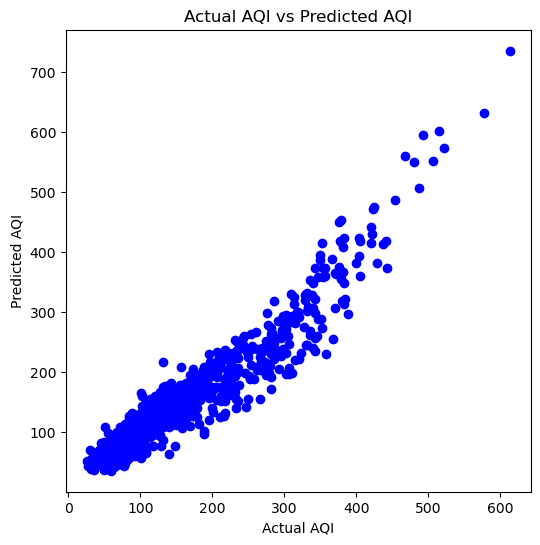

In [16]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, color='blue')
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual AQI vs Predicted AQI")
plt.show()

# STEP 12: Check Feature Importance (Coefficients)
# ------------------------------------------
# Shows how much each pollutant affects AQI

In [17]:
coefficients = pd.DataFrame({
    'Pollutant': X.columns,
    'Coefficient': model.coef_
})

print("\nFeature Importance:")
print(coefficients)


Feature Importance:
  Pollutant  Coefficient
0     PM2.5     0.856454
1      PM10     0.453694
2        NO    -0.160103
3       NO2    -0.178851
4       NOx     0.356639
5       NH3     0.232426


In [18]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))
